# Experiment 5: LLM Evaluation on Elamite Cuneiform
## Zero-shot & Few-shot POS Tagging and Lemmatization

**Research question:** Do large language models have any knowledge of Elamite cuneiform, and does prompting in Unicode vs. Latin transliteration affect performance?

**Models tested:**
- Claude (Anthropic API)
- GPT-4o (OpenAI API) — add your key
- Gemini (Google API) — add your key

**Tasks:**
1. POS classification (zero-shot + 5-shot)
2. Lemmatization (zero-shot + 5-shot)
3. Word boundary insertion (zero-shot)

**Each task is run twice:** once with Latin transliteration input, once with Unicode cuneiform input.

In [12]:
# ============================================================
# 0. SETUP
# ============================================================
!pip install -q anthropic openai pandas regex openpyxl google-generativeai

import pandas as pd
import numpy as np
import regex as re
import json, time, os
from collections import Counter
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

In [13]:
# ============================================================
# 0b. API KEYS — fill in yours
# ============================================================
# Option 1: Set directly
ANTHROPIC_API_KEY = ''  # sk-ant-...
OPENAI_API_KEY = ''     # sk-...
GOOGLE_API_KEY = ''     # AIza...

# Option 2: From Colab secrets (recommended)
try:
    from google.colab import userdata
    ANTHROPIC_API_KEY = ANTHROPIC_API_KEY or userdata.get('Claude')
    OPENAI_API_KEY = OPENAI_API_KEY or userdata.get('ChatGPT')
    GOOGLE_API_KEY = GOOGLE_API_KEY or userdata.get('Gemini')
except:
    pass

# Initialize clients
clients = {}

if ANTHROPIC_API_KEY:
    import anthropic
    clients['Claude'] = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    print('Claude: ready')

if OPENAI_API_KEY:
    from openai import OpenAI
    clients['GPT-4o'] = OpenAI(api_key=OPENAI_API_KEY)
    print('GPT-4o: ready')

if GOOGLE_API_KEY:
    import google.generativeai as genai
    genai.configure(api_key=GOOGLE_API_KEY)
    clients['Gemini'] = genai.GenerativeModel('gemini-2.0-flash')
    print('Gemini: ready')

print(f'\nActive models: {list(clients.keys())}')

Claude: ready
GPT-4o: ready
Gemini: ready

Active models: ['Claude', 'GPT-4o', 'Gemini']


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [14]:
# ============================================================
# 1. LOAD PREPROCESSED DATA
# Reproduces the v3 pipeline (condensed)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = 'data/'
DICT_PATH = BASE_PATH + 'Elamite_Lemma-base-draft.xlsx'
NASU_PATH = BASE_PATH + 'UnTN-Nasu texts Word-level.csv'
UNMATCHED_PATH_1 = BASE_PATH + 'unmatchednew_AAedit - unmatchednew.csv'
UNMATCHED_PATH_2 = BASE_PATH + 'unmatchednew - solonew.csv'

# Load dictionary
all_sheets = pd.read_excel(DICT_PATH, sheet_name=None)
target_tabs = ['ADJ', 'Noun', 'Verb', 'other', 'PN', 'PN-hyp', 'GN', 'DN', 'Magic']
columns_to_keep = ['transliteration', 'sorting', 'period', 'base', 'logogram',
    'morpheme_1', 'morpheme_2', 'morpheme_3', 'sense_hk', 'certainty-weight_hk',
    'sense_hk_qid', 'certainty-weight_MEGA', 'sense_MEGA_qid', 'POS', 'number', 'person']
combined = []
for name in target_tabs:
    if name in all_sheets:
        df = all_sheets[name]; df['category'] = name
        existing = [c for c in columns_to_keep if c in df.columns]
        combined.append(df[existing + ['category']])
final_dictionary = pd.concat(combined, ignore_index=True)

# Sign lists
sign_list = pd.read_json('https://raw.githubusercontent.com/situx/Nuolenna/master/sign_list.json', orient='index')
sign_list.columns = ['unicode']; sign_list['sign'] = sign_list.index.tolist()
sign_list = sign_list[['sign','unicode']].reset_index(drop=True)
akkademia = pd.read_csv('https://raw.githubusercontent.com/gaigutherz/Akkademia/master/cuneiform_to_unicode_fixed.csv')
concatenated = pd.merge(sign_list, akkademia, on=['sign','unicode'], how='outer', indicator=True)

unmatched = pd.read_csv(UNMATCHED_PATH_1)[['unmatched_sign','use']].dropna()
unmatched2 = pd.read_csv(UNMATCHED_PATH_2)[['value','SIGN']].dropna()
manual_dict = dict(zip(unmatched['unmatched_sign'], unmatched['use']))
manual_dict2 = dict(zip(unmatched2['value'].str.strip("[]' "), unmatched2['SIGN']))
unicode_dict = dict(zip(concatenated['sign'], concatenated['unicode']))
unicode_dict.update(manual_dict); unicode_dict.update(manual_dict2)

# Preprocessing functions
def normalize_for_unmatched_pass(s):
    if pd.isna(s): return ""
    s = str(s)
    s = re.sub(r"\(\s*md\s*\)", " m d ", s)
    s = re.sub(r"[.,:;!?()\[\]{}<>\\\"\"\"''/\\|*^`~]", " ", s)
    s = re.sub(r"[-\u2013\u2014]", " ", s)
    s = re.sub(r"([A-Za-z])(\d)([A-Za-z])", r"\1\2 \3", s)
    s = re.sub(r"(\d)([A-Za-z])", r"\1 \2", s)
    return re.sub(r"\s+", " ", s).strip()

def replace_with_unicode(text):
    return ' '.join([unicode_dict.get(s, s) for s in text.split()])

unicode_dict_v2 = dict(zip(concatenated['sign'].astype(str), concatenated['unicode'].astype(str)))
unicode_dict_v2.update(manual_dict); unicode_dict_v2.update(manual_dict2)

def final_unmatched_conversion_pass(unicode_text):
    txt = normalize_for_unmatched_pass(unicode_text)
    tokens = txt.split()
    out, unm = [], []
    for tok in tokens:
        if tok == 'md' and 'm' in unicode_dict_v2 and 'd' in unicode_dict_v2 and 'md' not in unicode_dict_v2:
            out.append(unicode_dict_v2['m']); out.append(unicode_dict_v2['d']); continue
        if tok in unicode_dict_v2: out.append(unicode_dict_v2[tok])
        else:
            out.append(tok)
            if re.search(r'\p{Latin}', tok): unm.append(tok)
    return ' '.join(out), unm

# Apply pipeline
to_unicode = final_dictionary.copy()
to_unicode['transliteration original'] = to_unicode['transliteration']
to_unicode['transliteration'] = to_unicode['transliteration'].astype(str).fillna('')
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace('-', ' ')
for ch in ['_','[',']','*','!','?','/',',',':',';','^','`']:
    to_unicode['transliteration'] = to_unicode['transliteration'].str.replace(ch, '', regex=False)
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace('.', ' ', regex=False)
to_unicode['transliteration'] = to_unicode['transliteration'].str.lower()
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace(r'~.*?……', '……', regex=True)
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace('X', '', regex=False)
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace('……', ' ', regex=False)
to_unicode['unicode'] = to_unicode['transliteration'].apply(replace_with_unicode)
tmp = to_unicode['unicode'].apply(final_unmatched_conversion_pass)
to_unicode['transliteration'] = to_unicode['transliteration original'].apply(normalize_for_unmatched_pass)
to_unicode['roman'] = tmp.apply(lambda x: len(x[1]) > 0)
to_unicode['unicode'] = tmp.apply(lambda x: x[0])
dict_clean = to_unicode[to_unicode['roman'] == False].copy()
dict_clean['repr_latin'] = dict_clean['transliteration']
dict_clean['repr_unicode'] = dict_clean['unicode']

print(f'Clean entries: {len(dict_clean)}')
print(f'POS distribution: {dict_clean["category"].value_counts().to_dict()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Clean entries: 13383
POS distribution: {'PN': 4992, 'Noun': 3852, 'Verb': 1500, 'GN': 1493, 'other': 687, 'ADJ': 538, 'DN': 301, 'PN-hyp': 20}


In [15]:
# ============================================================
# 2. PREPARE TEST SET
# ============================================================
# Sample a balanced test set for LLM evaluation
# We use fewer examples than the full dataset because API calls are slow/expensive

TEST_PER_CLASS = 30  # 30 per category
min_examples = 20
valid_pos = dict_clean['category'].value_counts()
valid_pos = valid_pos[valid_pos >= min_examples].index.tolist()

test_samples = []
fewshot_samples = []  # Separate pool for few-shot examples

for cat in valid_pos:
    cat_data = dict_clean[dict_clean['category'] == cat].sample(
        n=min(TEST_PER_CLASS + 10, len(dict_clean[dict_clean['category'] == cat])),
        random_state=SEED
    )
    # First 10 for few-shot pool, rest for testing
    fewshot_samples.append(cat_data.iloc[:5])
    test_samples.append(cat_data.iloc[5:5+TEST_PER_CLASS])

test_df = pd.concat(test_samples).reset_index(drop=True)
fewshot_df = pd.concat(fewshot_samples).reset_index(drop=True)

print(f'Test set: {len(test_df)} examples')
print(f'Few-shot pool: {len(fewshot_df)} examples')
print(f'Test distribution: {test_df["category"].value_counts().to_dict()}')

Test set: 225 examples
Few-shot pool: 40 examples
Test distribution: {'PN': 30, 'Noun': 30, 'Verb': 30, 'GN': 30, 'other': 30, 'ADJ': 30, 'DN': 30, 'PN-hyp': 15}


In [16]:
# ============================================================
# 3. LLM CALLING FUNCTIONS
# ============================================================

def call_claude(prompt, system="", max_tokens=100):
    """Call Claude API."""
    try:
        response = clients['Claude'].messages.create(
            model='claude-sonnet-4-20250514',
            max_tokens=max_tokens,
            system=system,
            messages=[{'role': 'user', 'content': prompt}]
        )
        return response.content[0].text.strip()
    except Exception as e:
        return f'ERROR: {e}'


def call_gpt4(prompt, system="", max_tokens=100):
    """Call GPT-4o API."""
    try:
        messages = []
        if system:
            messages.append({'role': 'system', 'content': system})
        messages.append({'role': 'user', 'content': prompt})
        response = clients['GPT-4o'].chat.completions.create(
            model='gpt-4o',
            messages=messages,
            max_tokens=max_tokens,
            temperature=0
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f'ERROR: {e}'


def call_gemini(prompt, system="", max_tokens=100):
    """Call Gemini API."""
    try:
        full_prompt = f"{system}\n\n{prompt}" if system else prompt
        response = clients['Gemini'].generate_content(full_prompt)
        return response.text.strip()
    except Exception as e:
        return f'ERROR: {e}'


def call_llm(model_name, prompt, system="", max_tokens=100):
    """Unified LLM caller."""
    if model_name == 'Claude':
        return call_claude(prompt, system, max_tokens)
    elif model_name == 'GPT-4o':
        return call_gpt4(prompt, system, max_tokens)
    elif model_name == 'Gemini':
        return call_gemini(prompt, system, max_tokens)
    return 'ERROR: unknown model'


print('LLM functions ready.')
print(f'Available: {list(clients.keys())}')

LLM functions ready.
Available: ['Claude', 'GPT-4o', 'Gemini']


In [17]:
# ============================================================
# 4. TASK 1: POS CLASSIFICATION
# ============================================================

SYSTEM_POS = """You are an expert in ancient Near Eastern languages, specifically Elamite cuneiform.
Your task is to classify Elamite words into one of these categories:
ADJ (adjective), DN (divine name), GN (geographical name), Noun, PN (personal name), Verb, other

Respond with ONLY the category label, nothing else. For example: Noun"""


def build_pos_prompt(word, repr_type, n_shot=0):
    """Build a POS classification prompt."""
    if repr_type == 'latin':
        script_label = 'Latin transliteration'
    else:
        script_label = 'Unicode cuneiform'

    prompt = ""

    # Add few-shot examples
    if n_shot > 0:
        prompt += f"Here are some examples of Elamite words in {script_label} with their categories:\n\n"
        col = 'repr_latin' if repr_type == 'latin' else 'repr_unicode'
        examples = fewshot_df.sample(n=min(n_shot, len(fewshot_df)), random_state=SEED)
        for _, row in examples.iterrows():
            prompt += f"Word: {row[col]}\nCategory: {row['category']}\n\n"
        prompt += "Now classify this word:\n\n"

    prompt += f"What is the category of this Elamite word ({script_label})?\n"
    prompt += f"Word: {word}\n"
    prompt += f"Category:"

    return prompt


def parse_pos_response(response):
    """Extract POS label from LLM response."""
    response = response.strip()
    # Try exact match first
    valid = ['ADJ', 'DN', 'GN', 'Noun', 'PN', 'PN-hyp', 'Verb', 'other']
    for v in valid:
        if response.lower() == v.lower():
            return v
    # Try to find a valid label anywhere in response
    for v in valid:
        if v.lower() in response.lower():
            return v
    return response[:20]  # Return truncated raw response if no match


print('POS prompts ready.')
# Test one prompt
sample = test_df.iloc[0]
print('\n--- Sample zero-shot Latin prompt ---')
print(build_pos_prompt(sample['repr_latin'], 'latin', n_shot=0))
print('\n--- Sample 5-shot Unicode prompt ---')
print(build_pos_prompt(sample['repr_unicode'], 'unicode', n_shot=5))

POS prompts ready.

--- Sample zero-shot Latin prompt ---
What is the category of this Elamite word (Latin transliteration)?
Word: hh iš ba ráš du ma
Category:

--- Sample 5-shot Unicode prompt ---
Here are some examples of Elamite words in Unicode cuneiform with their categories:

Word: 𒄷 𒄷 𒉡 𒊑 𒆠
Category: GN

Word: 𒀸 𒄯 𒊓 𒀝 𒊏
Category: GN

Word: 𒀸 𒌝 𒁍 𒊏 𒅖
Category: GN

Word: 𒂟 𒈾 𒋗
Category: ADJ

Word: 𒄬 𒋡 𒌋 𒈠 𒋡
Category: PN

Now classify this word:

What is the category of this Elamite word (Unicode cuneiform)?
Word: 𒄬 𒅖 𒁀 𒌇 𒁺 𒈠
Category:


In [18]:
# ============================================================
# 5. RUN POS CLASSIFICATION
# ============================================================

def run_pos_experiment(model_name, repr_type, n_shot, test_data):
    """Run POS classification on the test set."""
    col = 'repr_latin' if repr_type == 'latin' else 'repr_unicode'
    preds = []
    golds = []

    print(f'  Running {model_name} | {repr_type} | {n_shot}-shot | {len(test_data)} examples...')

    for i, (_, row) in enumerate(test_data.iterrows()):
        prompt = build_pos_prompt(row[col], repr_type, n_shot)
        response = call_llm(model_name, prompt, SYSTEM_POS, max_tokens=30)
        pred = parse_pos_response(response)
        preds.append(pred)
        golds.append(row['category'])

        # Rate limiting
        if (i + 1) % 20 == 0:
            print(f'    {i+1}/{len(test_data)} done')
            time.sleep(1)

    # Compute metrics
    valid_labels = sorted(set(golds))
    f1 = f1_score(golds, preds, labels=valid_labels, average='macro', zero_division=0)
    accuracy = sum(1 for g, p in zip(golds, preds) if g == p) / len(golds)

    print(f'  → Accuracy: {accuracy:.3f} | Macro-F1: {f1:.3f}')
    print(classification_report(golds, preds, labels=valid_labels, zero_division=0))

    return {
        'model': model_name, 'repr': repr_type, 'n_shot': n_shot,
        'accuracy': accuracy, 'f1': f1,
        'preds': preds, 'golds': golds
    }


# Run all combinations
pos_results = []

for model_name in clients.keys():
    for repr_type in ['latin', 'unicode']:
        for n_shot in [0, 5]:
            print(f'\n{"="*50}')
            r = run_pos_experiment(model_name, repr_type, n_shot, test_df)
            pos_results.append(r)
            time.sleep(2)  # Pause between experiments

print(f'\nCompleted {len(pos_results)} POS experiments.')


  Running Claude | latin | 0-shot | 225 examples...
    20/225 done
    40/225 done
    60/225 done
    80/225 done
    100/225 done
    120/225 done
    140/225 done
    160/225 done
    180/225 done
    200/225 done
    220/225 done
  → Accuracy: 0.302 | Macro-F1: 0.241
              precision    recall  f1-score   support

         ADJ       0.00      0.00      0.00        30
          DN       0.93      0.90      0.92        30
          GN       0.67      0.20      0.31        30
        Noun       0.00      0.00      0.00        30
          PN       0.38      0.10      0.16        30
      PN-hyp       0.00      0.00      0.00        15
        Verb       0.19      0.47      0.27        30
       other       0.18      0.60      0.27        30

    accuracy                           0.30       225
   macro avg       0.29      0.28      0.24       225
weighted avg       0.31      0.30      0.26       225


  Running Claude | latin | 5-shot | 225 examples...
    20/225 done
    40

    20/225 done


    40/225 done


    60/225 done


    80/225 done


...

    160/225 done


    180/225 done


    200/225 done


    220/225 done


  → Accuracy: 0.000 | Macro-F1: 0.000
              precision    recall  f1-score   support

         ADJ       0.00      0.00      0.00      30.0
          DN       0.00      0.00      0.00      30.0
          GN       0.00      0.00      0.00      30.0
        Noun       0.00      0.00      0.00      30.0
          PN       0.00      0.00      0.00      30.0
      PN-hyp       0.00      0.00      0.00      15.0
        Verb       0.00      0.00      0.00      30.0
       other       0.00      0.00      0.00      30.0

   micro avg       0.00      0.00      0.00     225.0
   macro avg       0.00      0.00      0.00     225.0
weighted avg       0.00      0.00      0.00     225.0


Completed 12 POS experiments.


In [19]:
# ============================================================
# 6. TASK 2: LEMMATIZATION
# ============================================================

SYSTEM_LEMMA = """You are an expert in Elamite, an ancient language of Iran written in cuneiform.
Given an inflected Elamite word, predict its base lemma (dictionary form).
Respond with ONLY the lemma, nothing else."""

# Prepare lemmatization test set
lemma_data = dict_clean[['repr_latin', 'repr_unicode', 'base', 'category']].copy()
lemma_data = lemma_data.dropna(subset=['base'])
lemma_data['base'] = lemma_data['base'].astype(str)
lemma_data = lemma_data[lemma_data['base'].str.strip() != '']
lemma_data = lemma_data.drop_duplicates(subset=['repr_latin', 'base']).reset_index(drop=True)

# Sample test set
lemma_test = lemma_data.sample(n=min(150, len(lemma_data)), random_state=SEED).reset_index(drop=True)
lemma_fewshot = lemma_data[~lemma_data.index.isin(lemma_test.index)].sample(n=10, random_state=SEED)

print(f'Lemma test: {len(lemma_test)} pairs')
print(f'Lemma few-shot pool: {len(lemma_fewshot)} examples')


def build_lemma_prompt(word, repr_type, n_shot=0):
    script_label = 'Latin transliteration' if repr_type == 'latin' else 'Unicode cuneiform'
    col = 'repr_latin' if repr_type == 'latin' else 'repr_unicode'
    prompt = ""

    if n_shot > 0:
        prompt += f"Examples of Elamite words ({script_label}) and their base lemmas:\n\n"
        for _, row in lemma_fewshot.head(n_shot).iterrows():
            prompt += f"Word: {row[col]}\nLemma: {row['base']}\n\n"
        prompt += "Now predict the lemma:\n\n"

    prompt += f"What is the base lemma of this Elamite word ({script_label})?\n"
    prompt += f"Word: {word}\nLemma:"
    return prompt


def run_lemma_experiment(model_name, repr_type, n_shot):
    col = 'repr_latin' if repr_type == 'latin' else 'repr_unicode'
    exact, char_correct, char_total = 0, 0, 0
    examples = []

    print(f'  Running {model_name} | {repr_type} | {n_shot}-shot | {len(lemma_test)} examples...')

    for i, (_, row) in enumerate(lemma_test.iterrows()):
        prompt = build_lemma_prompt(row[col], repr_type, n_shot)
        response = call_llm(model_name, prompt, SYSTEM_LEMMA, max_tokens=50)
        pred = response.strip().split('\n')[0].strip()
        gold = row['base']

        if pred == gold:
            exact += 1

        for pc, gc in zip(pred, gold):
            if pc == gc: char_correct += 1
            char_total += 1
        char_total += abs(len(pred) - len(gold))

        if len(examples) < 15:
            examples.append((row[col], gold, pred, pred == gold))

        if (i + 1) % 30 == 0:
            print(f'    {i+1}/{len(lemma_test)} done')
            time.sleep(1)

    exact_acc = exact / len(lemma_test)
    char_acc = char_correct / max(char_total, 1)

    print(f'  → Exact match: {exact_acc:.3f} | Char accuracy: {char_acc:.3f}')
    print(f'  Examples:')
    for src, gold, pred, correct in examples[:8]:
        mark = '✓' if correct else '✗'
        print(f'    {mark} {src[:30]:30s} → gold: {gold:15s} pred: {pred}')

    return {
        'model': model_name, 'repr': repr_type, 'n_shot': n_shot,
        'exact_acc': exact_acc, 'char_acc': char_acc
    }


# Run
lemma_results = []
for model_name in clients.keys():
    for repr_type in ['latin', 'unicode']:
        for n_shot in [0, 5]:
            print(f'\n{"="*50}')
            r = run_lemma_experiment(model_name, repr_type, n_shot)
            lemma_results.append(r)
            time.sleep(2)

Lemma test: 150 pairs
Lemma few-shot pool: 10 examples

  Running Claude | latin | 0-shot | 150 examples...
    30/150 done
    60/150 done
    90/150 done
    120/150 done
    150/150 done
  → Exact match: 0.067 | Char accuracy: 0.291
  Examples:
    ✗ GIŠ za pan nu ti ip            → gold: nuti            pred: zappa
    ✗ ku ut tuk ki ip                → gold: kutu-           pred: kutukki
    ✗ ra ab ba ak na                 → gold: rapa            pred: rabak
    ✗ sa nu ma ak                    → gold: sahnu-          pred: sanumak
    ✗ zi la ni e ip                  → gold: sila            pred: zila
    ✗ be ip ši ya ma                 → gold: peši            pred: beipšiyam
    ✗ hh ba be ip                    → gold: GN              pred: habe
    ✗ zu un ki ip                    → gold: sunki           pred: zunkik

  Running Claude | latin | 5-shot | 150 examples...
    30/150 done
    60/150 done
    90/150 done
    120/150 done
    150/150 done
  → Exact match: 0.153 | C

    30/150 done


    60/150 done


    90/150 done


    120/150 done


...

    30/150 done


    60/150 done


    90/150 done


    120/150 done


    150/150 done
  → Exact match: 0.000 | Char accuracy: 0.000
  Examples:
    ✗ 𒄑 𒍝 𒉼 𒉡 𒋾 𒅁                    → gold: nuti            pred: ERROR: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: This model models/gemini-2.0-flash is no longer available to new users. Please update your code to use a newer model for the latest features and improvements.
    ✗ 𒆪 𒌓 𒌇 𒆠 𒅁                      → gold: kutu-           pred: ERROR: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: This model models/gemini-2.0-flash is no longer available to new users. Please update your code to use a newer model for the latest features and improvements.
    ✗ 𒊏 𒀊 𒁀 𒀝 𒈾                      → gold: rapa            pred: ERROR: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-en

In [20]:
# ============================================================
# 7. TASK 3: WORD BOUNDARY INSERTION
# ============================================================

SYSTEM_BOUNDARY = """You are an expert in Elamite cuneiform.
Given a continuous string of Unicode cuneiform signs with no spaces, insert spaces at word boundaries.
Respond with ONLY the segmented text, nothing else."""

# Prepare boundary test data from Nasu corpus
nasu_df = pd.read_csv(NASU_PATH)
nasu_df['translit_clean'] = nasu_df['transliteration'].apply(normalize_for_unmatched_pass)
nasu_df['unicode'] = nasu_df['translit_clean'].apply(
    lambda x: final_unmatched_conversion_pass(replace_with_unicode(x))[0] if pd.notna(x) and x else ''
)
docs_unicode = nasu_df.groupby('id_text')['unicode'].apply(lambda x: ' '.join(x.dropna())).tolist()

# Use shorter documents for boundary testing
boundary_test = []
for doc in docs_unicode:
    if doc and 5 < len(doc.split()) < 30:
        continuous = doc.replace(' ', '')
        if len(continuous) > 3:
            boundary_test.append({'segmented': doc, 'continuous': continuous})

boundary_test = boundary_test[:30]  # Limit for API costs
print(f'Boundary test: {len(boundary_test)} documents')


def run_boundary_experiment(model_name):
    print(f'  Running {model_name} | word boundaries | {len(boundary_test)} docs...')
    exact, total = 0, 0
    char_f1s = []

    for i, d in enumerate(boundary_test):
        prompt = f"Insert spaces at word boundaries in this Elamite cuneiform text:\n{d['continuous']}"
        response = call_llm(model_name, prompt, SYSTEM_BOUNDARY, max_tokens=300)
        pred = response.strip().split('\n')[0].strip()
        gold = d['segmented']

        if pred == gold:
            exact += 1
        total += 1

        # Compute boundary positions for F1
        def get_boundaries(text):
            positions, pos = [], 0
            for ch in text:
                if ch == ' ': positions.append(pos)
                else: pos += 1
            return set(positions)

        gold_b = get_boundaries(gold)
        pred_b = get_boundaries(pred)
        if gold_b and pred_b:
            tp = len(gold_b & pred_b)
            p = tp / len(pred_b) if pred_b else 0
            r = tp / len(gold_b) if gold_b else 0
            f1 = 2*p*r/(p+r) if (p+r) else 0
            char_f1s.append(f1)

        if (i + 1) % 10 == 0:
            time.sleep(1)

    exact_acc = exact / total
    mean_f1 = np.mean(char_f1s) if char_f1s else 0
    print(f'  → Exact doc match: {exact_acc:.3f} | Mean boundary F1: {mean_f1:.3f}')
    return {'model': model_name, 'exact_acc': exact_acc, 'boundary_f1': mean_f1}


boundary_results = []
for model_name in clients.keys():
    print(f'\n{"="*50}')
    r = run_boundary_experiment(model_name)
    boundary_results.append(r)
    time.sleep(2)

Boundary test: 2 documents

  Running Claude | word boundaries | 2 docs...
  → Exact doc match: 0.000 | Mean boundary F1: 0.493

  Running GPT-4o | word boundaries | 2 docs...
  → Exact doc match: 0.000 | Mean boundary F1: 0.493

  Running Gemini | word boundaries | 2 docs...


  → Exact doc match: 0.000 | Mean boundary F1: 0.059


In [21]:
# ============================================================
# 8. RESULTS COMPARISON: LLMs vs TRAINED MODELS
# ============================================================

print('=' * 70)
print('FULL RESULTS: LLMs vs TRAINED MODELS')
print('=' * 70)

# --- POS ---
print('\n--- POS Classification (Macro-F1) ---')
print(f'{"Model":30s} {"Latin":>8s} {"Unicode":>8s}')
print('-' * 50)
# Trained baselines
print(f'{"Char n-gram LR (trained)":30s} {"0.567":>8s} {"0.582":>8s}')
print(f'{"BiLSTM (trained)":30s} {"0.586":>8s} {"0.568":>8s}')
# LLM results
for r in pos_results:
    label = f"{r['model']} ({r['n_shot']}-shot)"
    if r['repr'] == 'latin':
        # Find matching unicode result
        unicode_r = next((x for x in pos_results
                         if x['model'] == r['model'] and x['n_shot'] == r['n_shot']
                         and x['repr'] == 'unicode'), None)
        u_f1 = f"{unicode_r['f1']:.3f}" if unicode_r else '—'
        print(f'{label:30s} {r["f1"]:>8.3f} {u_f1:>8s}')

# --- Lemmatization ---
print('\n--- Lemmatization (Exact Match) ---')
print(f'{"Model":30s} {"Latin":>8s} {"Unicode":>8s}')
print('-' * 50)
print(f'{"LSTM seq2seq (trained)":30s} {"0.474":>8s} {"0.359":>8s}')
for r in lemma_results:
    if r['repr'] == 'latin':
        label = f"{r['model']} ({r['n_shot']}-shot)"
        unicode_r = next((x for x in lemma_results
                         if x['model'] == r['model'] and x['n_shot'] == r['n_shot']
                         and x['repr'] == 'unicode'), None)
        u_acc = f"{unicode_r['exact_acc']:.3f}" if unicode_r else '—'
        print(f'{label:30s} {r["exact_acc"]:>8.3f} {u_acc:>8s}')

# --- Word boundaries ---
print('\n--- Word Boundaries (F1) ---')
print(f'{"Model":30s} {"F1":>8s}')
print('-' * 40)
print(f'{"Trans. prob. (trained)":30s} {"0.993":>8s}')
for r in boundary_results:
    print(f'{r["model"]:30s} {r["boundary_f1"]:>8.3f}')

print('\n' + '=' * 70)

FULL RESULTS: LLMs vs TRAINED MODELS

--- POS Classification (Macro-F1) ---
Model                             Latin  Unicode
--------------------------------------------------
Char n-gram LR (trained)          0.567    0.582
BiLSTM (trained)                  0.586    0.568
Claude (0-shot)                   0.241    0.262
Claude (5-shot)                   0.265    0.285
GPT-4o (0-shot)                   0.252    0.185
GPT-4o (5-shot)                   0.294    0.223
Gemini (0-shot)                   0.000    0.000
Gemini (5-shot)                   0.000    0.000

--- Lemmatization (Exact Match) ---
Model                             Latin  Unicode
--------------------------------------------------
LSTM seq2seq (trained)            0.474    0.359
Claude (0-shot)                   0.067    0.020
Claude (5-shot)                   0.153    0.047
GPT-4o (0-shot)                   0.047    0.000
GPT-4o (5-shot)                   0.160    0.013
Gemini (0-shot)                   0.000    0.000
G

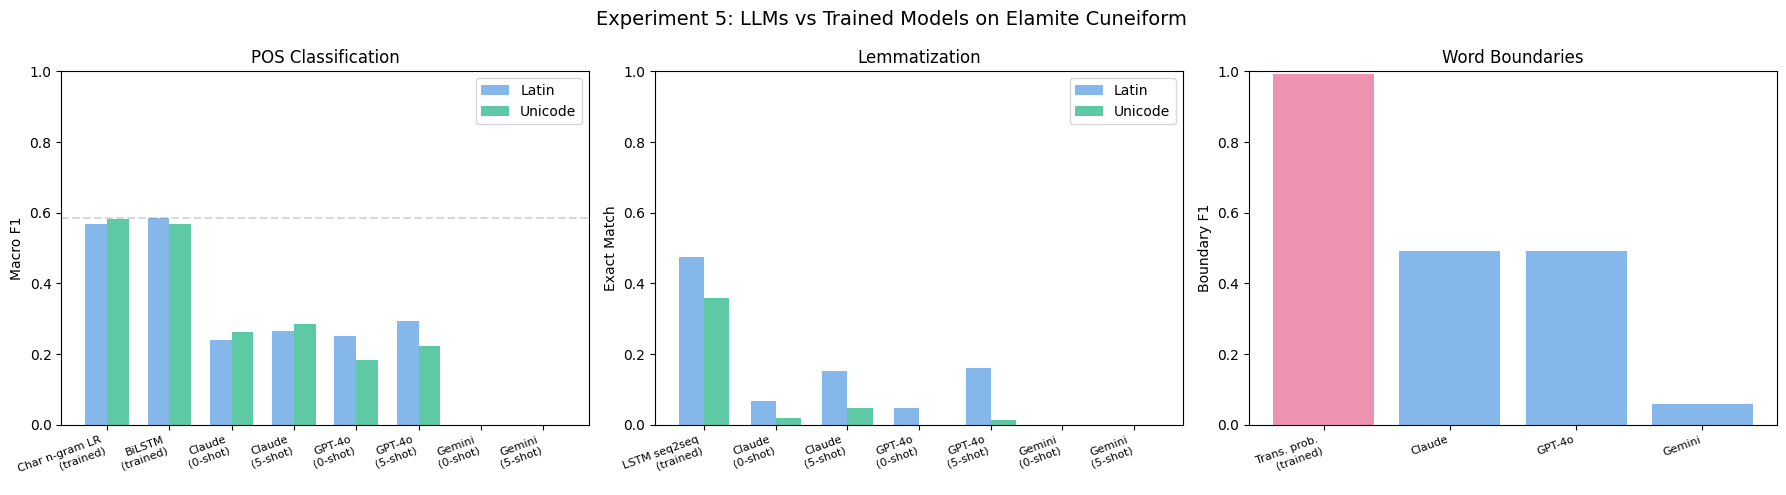

Saved: exp5_llm_comparison.png


In [22]:
# ============================================================
# 9. VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- POS comparison ---
ax = axes[0]
models_pos = ['Char n-gram LR\n(trained)', 'BiLSTM\n(trained)']
latin_f1s = [0.567, 0.586]
unicode_f1s = [0.582, 0.568]

for r in pos_results:
    if r['repr'] == 'latin':
        label = f"{r['model']}\n({r['n_shot']}-shot)"
        models_pos.append(label)
        latin_f1s.append(r['f1'])
        unicode_r = next((x for x in pos_results
                         if x['model'] == r['model'] and x['n_shot'] == r['n_shot']
                         and x['repr'] == 'unicode'), None)
        unicode_f1s.append(unicode_r['f1'] if unicode_r else 0)

x = np.arange(len(models_pos)); w = 0.35
ax.bar(x-w/2, latin_f1s, w, label='Latin', color='#85B7EB')
ax.bar(x+w/2, unicode_f1s, w, label='Unicode', color='#5DCAA5')
ax.set_xticks(x); ax.set_xticklabels(models_pos, fontsize=8, rotation=20, ha='right')
ax.set_ylabel('Macro F1'); ax.set_title('POS Classification')
ax.legend(); ax.set_ylim(0, 1)
ax.axhline(y=0.586, color='gray', linestyle='--', alpha=0.3, label='Best trained')

# --- Lemmatization ---
ax = axes[1]
models_lem = ['LSTM seq2seq\n(trained)']
latin_lem = [0.474]
unicode_lem = [0.359]

for r in lemma_results:
    if r['repr'] == 'latin':
        label = f"{r['model']}\n({r['n_shot']}-shot)"
        models_lem.append(label)
        latin_lem.append(r['exact_acc'])
        unicode_r = next((x for x in lemma_results
                         if x['model'] == r['model'] and x['n_shot'] == r['n_shot']
                         and x['repr'] == 'unicode'), None)
        unicode_lem.append(unicode_r['exact_acc'] if unicode_r else 0)

x = np.arange(len(models_lem))
ax.bar(x-w/2, latin_lem, w, label='Latin', color='#85B7EB')
ax.bar(x+w/2, unicode_lem, w, label='Unicode', color='#5DCAA5')
ax.set_xticks(x); ax.set_xticklabels(models_lem, fontsize=8, rotation=20, ha='right')
ax.set_ylabel('Exact Match'); ax.set_title('Lemmatization')
ax.legend(); ax.set_ylim(0, 1)

# --- Word boundaries ---
ax = axes[2]
models_bd = ['Trans. prob.\n(trained)']
bd_f1s = [0.993]
for r in boundary_results:
    models_bd.append(r['model'])
    bd_f1s.append(r['boundary_f1'])

colors = ['#ED93B1'] + ['#85B7EB'] * len(boundary_results)
ax.bar(range(len(models_bd)), bd_f1s, color=colors)
ax.set_xticks(range(len(models_bd)))
ax.set_xticklabels(models_bd, fontsize=8, rotation=20, ha='right')
ax.set_ylabel('Boundary F1'); ax.set_title('Word Boundaries')
ax.set_ylim(0, 1)

plt.suptitle('Experiment 5: LLMs vs Trained Models on Elamite Cuneiform', fontsize=14)
plt.tight_layout()
plt.savefig('exp5_llm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp5_llm_comparison.png')